# Chapter 5 - Merge HLL++ Precision Mismatch

Notebook per analizzare la matrice minima di `precision mismatch` su `HyperLogLog++`.

Obiettivi:
- caricare tutti i CSV `results_merge_heterogeneous.csv` della Phase 5;
- confrontare `reject`, `unsafe_naive_merge` e `reduce_then_merge`;
- verificare che `reduce_then_merge` coincida con seriale e baseline a precisione bassa;
- quantificare la degradazione del merge naïve sui casi `recoverable`.


In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / '.git').exists():
            return candidate
    raise RuntimeError('Repository root non trovata')


REPO = find_repo_root(Path.cwd().resolve())
RESULTS_ROOT = REPO / 'results'
OUT_DIR = REPO / 'thesis' / 'figures' / 'results'
OUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_GLOB = 'merge_hpp_precision_mismatch_min*/**/results_merge_heterogeneous.csv'

PAIRING_ORDER = ['10->14', '14->10', '10->18', '18->10', '14->18', '18->14']
PAIR_GROUP_ORDER = ['10 vs 14', '10 vs 18', '14 vs 18']
STRATEGY_ORDER = ['reject', 'unsafe_naive_merge', 'reduce_then_merge']

print('REPO:', REPO)
print('RESULTS_ROOT:', RESULTS_ROOT)
print('OUT_DIR:', OUT_DIR)
print('RESULTS_GLOB:', RESULTS_GLOB)


REPO: /home/daniele/Dev/satp-cpp
RESULTS_ROOT: /home/daniele/Dev/satp-cpp/results
OUT_DIR: /home/daniele/Dev/satp-cpp/thesis/figures/results
RESULTS_GLOB: merge_hpp_precision_mismatch_min*/**/results_merge_heterogeneous.csv


In [2]:
def parse_meta(path: Path) -> dict:
    rel = path.relative_to(RESULTS_ROOT)
    namespace = rel.parts[0]
    hash_cfg = rel.parts[3]
    params = rel.parts[4]

    m_ns = re.match(r'merge_hpp_precision_mismatch_min_(\d+)_(\d+)_d_(\d+)$', namespace)
    if not m_ns:
        raise ValueError(f'Namespace non riconosciuto: {namespace}')
    left_k_ns, right_k_ns, d_raw = m_ns.groups()

    m_hash = re.match(r'left_(.+?)_seed_(\d+)_right_(.+?)_seed_(\d+)$', hash_cfg)
    if not m_hash:
        raise ValueError(f'Configurazione hash non riconosciuta: {hash_cfg}')
    left_hash, left_seed, right_hash, right_seed = m_hash.groups()

    m_params = re.match(r'left_k_(\d+)_right_k_(\d+)_strategy_(.+)$', params)
    if not m_params:
        raise ValueError(f'Parametri non riconosciuti: {params}')
    left_k, right_k, strategy = m_params.groups()

    d = int(d_raw)
    rho = int(round(10_000_000 / d))
    left_k = int(left_k)
    right_k = int(right_k)
    pair_group = f'{min(left_k, right_k)} vs {max(left_k, right_k)}'

    return {
        'namespace': namespace,
        'd': d,
        'rho': rho,
        'left_hash': left_hash,
        'right_hash': right_hash,
        'left_hash_seed': int(left_seed),
        'right_hash_seed': int(right_seed),
        'left_k': left_k,
        'right_k': right_k,
        'pairing': f'{left_k}->{right_k}',
        'pair_group': pair_group,
        'strategy': strategy,
    }


frames = []
for csv_path in sorted(RESULTS_ROOT.glob(RESULTS_GLOB)):
    meta = parse_meta(csv_path)
    frame = pd.read_csv(csv_path)
    for key, value in meta.items():
        frame[key] = value
    frames.append(frame)

if not frames:
    raise RuntimeError('Nessun CSV trovato per la campagna precision mismatch')

df = pd.concat(frames, ignore_index=True)
df['pairing'] = pd.Categorical(df['pairing'], categories=PAIRING_ORDER, ordered=True)
df['pair_group'] = pd.Categorical(df['pair_group'], categories=PAIR_GROUP_ORDER, ordered=True)
df['strategy'] = pd.Categorical(df['strategy'], categories=STRATEGY_ORDER, ordered=True)
df['degradation_ratio'] = df['error_merge_rel_exact'] / df['error_serial_rel_exact']
df['baseline_gap_rel'] = (df['estimate_merge'] - df['baseline_homogeneous']).abs() / df['exact_union']

print('files:', len(frames))
print('rows:', len(df))
print('pairings:', sorted(df['pairing'].dropna().unique().tolist()))
print('pair groups:', sorted(df['pair_group'].dropna().unique().tolist()))
print('strategies:', sorted(df['strategy'].dropna().unique().tolist()))
print('validities:', sorted(df['validity'].unique().tolist()))
print('d values:', sorted(df['d'].unique().tolist()))
print('rho values:', sorted(df['rho'].unique().tolist()))

display(df.head())


files: 54
rows: 1350
pairings: ['10->14', '10->18', '14->10', '14->18', '18->10', '18->14']
pair groups: ['10 vs 14', '10 vs 18', '14 vs 18']
strategies: ['reduce_then_merge', 'reject', 'unsafe_naive_merge']
validities: ['recoverable']
d values: [100000, 1000000, 10000000]
rho values: [1, 10, 100]


,algorithm,mode,pairs,sample_size,pair_index,dataset_seed,left_hash,right_hash,left_hash_seed,right_hash_seed,...,delta_vs_baseline,namespace,d,rho,left_k,right_k,pairing,pair_group,degradation_ratio,baseline_gap_rel
0,HyperLogLog++,merge_heterogeneous,25,10000000,0,21041998,xxhash64,xxhash64,21041998,21041998,...,0.0,merge_hpp_precision_mismatch_min_10_14_d_100000,100000,100,10,14,10->14,10 vs 14,1.0,0.0
1,HyperLogLog++,merge_heterogeneous,25,10000000,1,21041998,xxhash64,xxhash64,21041998,21041998,...,0.0,merge_hpp_precision_mismatch_min_10_14_d_100000,100000,100,10,14,10->14,10 vs 14,1.0,0.0
2,HyperLogLog++,merge_heterogeneous,25,10000000,2,21041998,xxhash64,xxhash64,21041998,21041998,...,0.0,merge_hpp_precision_mismatch_min_10_14_d_100000,100000,100,10,14,10->14,10 vs 14,1.0,0.0
3,HyperLogLog++,merge_heterogeneous,25,10000000,3,21041998,xxhash64,xxhash64,21041998,21041998,...,0.0,merge_hpp_precision_mismatch_min_10_14_d_100000,100000,100,10,14,10->14,10 vs 14,1.0,0.0
4,HyperLogLog++,merge_heterogeneous,25,10000000,4,21041998,xxhash64,xxhash64,21041998,21041998,...,0.0,merge_hpp_precision_mismatch_min_10_14_d_100000,100000,100,10,14,10->14,10 vs 14,1.0,0.0


In [3]:
summary_runs = (
    df.groupby(['pairing', 'pair_group', 'strategy', 'validity', 'd', 'rho'], dropna=False)
      .agg(
          pairs=('pair_index', 'size'),
          merge_rel_mean=('error_merge_rel_exact', 'mean'),
          merge_rel_median=('error_merge_rel_exact', 'median'),
          merge_rel_max=('error_merge_rel_exact', 'max'),
          serial_rel_mean=('error_serial_rel_exact', 'mean'),
          baseline_gap_abs_mean=('delta_vs_baseline', 'mean'),
          baseline_gap_abs_max=('delta_vs_baseline', 'max'),
          baseline_gap_rel_mean=('baseline_gap_rel', 'mean'),
          degradation_ratio_mean=('degradation_ratio', 'mean'),
          merge_eq_serial_all=('estimate_merge', lambda s: ((s == df.loc[s.index, 'estimate_serial']) | (s.isna() & df.loc[s.index, 'estimate_serial'].isna())).all()),
          merge_eq_baseline_all=('estimate_merge', lambda s: ((s == df.loc[s.index, 'baseline_homogeneous']) | (s.isna() & df.loc[s.index, 'baseline_homogeneous'].isna())).all()),
      )
      .reset_index()
      .sort_values(['pairing', 'strategy', 'd'])
)

summary_global = (
    df.groupby(['strategy', 'validity'], dropna=False)
      .agg(
          pairs=('pair_index', 'size'),
          merge_rel_mean=('error_merge_rel_exact', 'mean'),
          merge_rel_median=('error_merge_rel_exact', 'median'),
          merge_rel_max=('error_merge_rel_exact', 'max'),
          serial_rel_mean=('error_serial_rel_exact', 'mean'),
          baseline_gap_abs_mean=('delta_vs_baseline', 'mean'),
          baseline_gap_abs_max=('delta_vs_baseline', 'max'),
          degradation_ratio_mean=('degradation_ratio', 'mean'),
      )
      .reset_index()
      .sort_values(['strategy'])
)

summary_pair_group = (
    df.groupby(['pair_group', 'strategy', 'd', 'rho'], dropna=False)
      .agg(
          merge_rel_mean=('error_merge_rel_exact', 'mean'),
          serial_rel_mean=('error_serial_rel_exact', 'mean'),
          baseline_gap_rel_mean=('baseline_gap_rel', 'mean'),
          degradation_ratio_mean=('degradation_ratio', 'mean'),
      )
      .reset_index()
      .sort_values(['pair_group', 'strategy', 'd'])
)

consistency_checks = pd.DataFrame([
    {
        'check': 'reduce_then_merge == serial for all pairs',
        'value': bool(summary_runs.query("strategy == 'reduce_then_merge'")['merge_eq_serial_all'].all()),
    },
    {
        'check': 'reduce_then_merge == baseline for all pairs',
        'value': bool(summary_runs.query("strategy == 'reduce_then_merge'")['merge_eq_baseline_all'].all()),
    },
    {
        'check': 'reject produces NaN merge estimates',
        'value': bool(df.query("strategy == 'reject'")['estimate_merge'].isna().all()),
    },
])

summary_global.to_csv(RESULTS_ROOT / 'merge_hpp_precision_mismatch_summary_global.csv', index=False)
summary_runs.to_csv(RESULTS_ROOT / 'merge_hpp_precision_mismatch_summary_runs.csv', index=False)
summary_pair_group.to_csv(RESULTS_ROOT / 'merge_hpp_precision_mismatch_pair_groups.csv', index=False)

display(summary_global)
display(summary_runs.head(18))
display(consistency_checks)


,strategy,validity,pairs,merge_rel_mean,merge_rel_median,merge_rel_max,serial_rel_mean,baseline_gap_abs_mean,baseline_gap_abs_max,degradation_ratio_mean
0,reject,recoverable,450,NaN,NaN,NaN,0.016651,NaN,NaN,NaN
1,unsafe_naive_merge,recoverable,450,0.363882,0.053305,1.061378,0.016651,3.387887e+06,10449611.0,32.370386
2,reduce_then_merge,recoverable,450,0.016651,0.014152,0.057418,0.016651,0.000000e+00,0.0,1.000000


,pairing,pair_group,strategy,validity,d,rho,pairs,merge_rel_mean,merge_rel_median,merge_rel_max,serial_rel_mean,baseline_gap_abs_mean,baseline_gap_abs_max,baseline_gap_rel_mean,degradation_ratio_mean,merge_eq_serial_all,merge_eq_baseline_all
0,10->14,10 vs 14,reject,recoverable,100000,100,25,NaN,NaN,NaN,0.024328,NaN,NaN,NaN,NaN,False,False
1,10->14,10 vs 14,reject,recoverable,1000000,10,25,NaN,NaN,NaN,0.023031,NaN,NaN,NaN,NaN,False,False
2,10->14,10 vs 14,reject,recoverable,10000000,1,25,NaN,NaN,NaN,0.016417,NaN,NaN,NaN,NaN,False,False
3,10->14,10 vs 14,unsafe_naive_merge,recoverable,100000,100,25,0.033188,0.031143,0.073787,0.024328,4584.72,16088.0,0.023038,2.250120,False,False
4,10->14,10 vs 14,unsafe_naive_merge,recoverable,1000000,10,25,0.044560,0.038441,0.112764,0.023031,110469.80,238690.0,0.058142,4.394868,False,False
5,10->14,10 vs 14,unsafe_naive_merge,recoverable,10000000,1,25,1.061378,1.061378,1.061378,0.016417,10449611.00,10449611.0,1.044961,64.651936,False,False
6,10->14,10 vs 14,reduce_then_merge,recoverable,100000,100,25,0.024328,0.022107,0.057418,0.024328,0.00,0.0,0.000000,1.000000,True,True
7,10->14,10 vs 14,reduce_then_merge,recoverable,1000000,10,25,0.023031,0.020164,0.047110,0.023031,0.00,0.0,0.000000,1.000000,True,True
8,10->14,10 vs 14,reduce_then_merge,recoverable,10000000,1,25,0.016417,0.016417,0.016417,0.016417,0.00,0.0,0.000000,1.000000,True,True
9,14->10,10 vs 14,reject,recoverable,100000,100,25,NaN,NaN,NaN,0.024328,NaN,NaN,NaN,NaN,False,False


,check,value
0,reduce_then_merge == serial for all pairs,True
1,reduce_then_merge == baseline for all pairs,True
2,reject produces NaN merge estimates,True


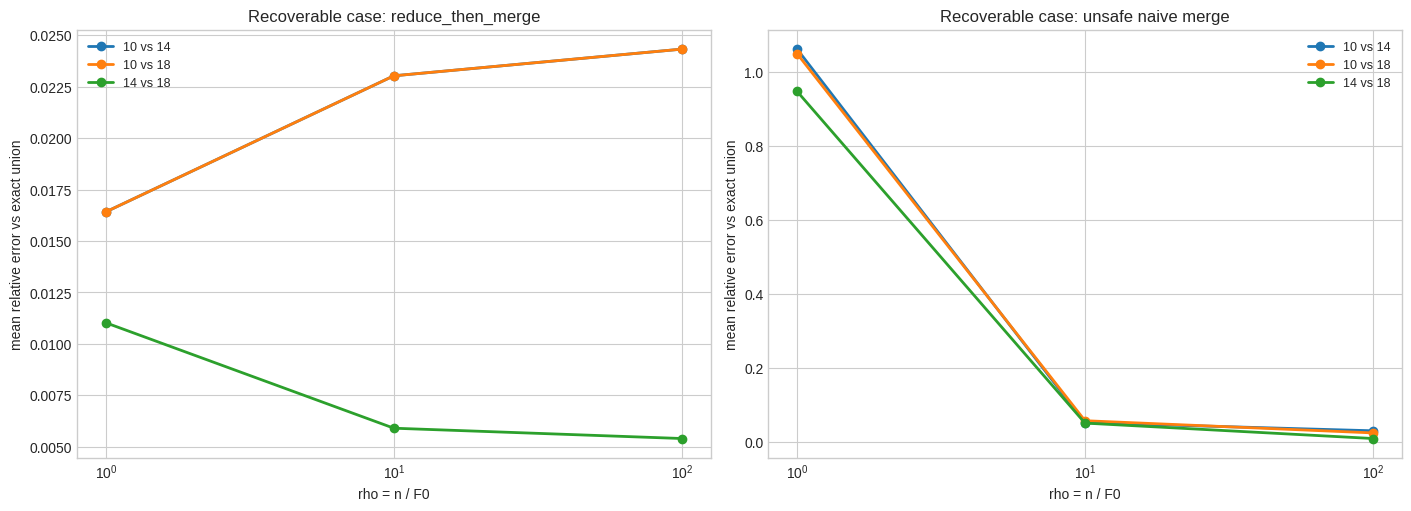

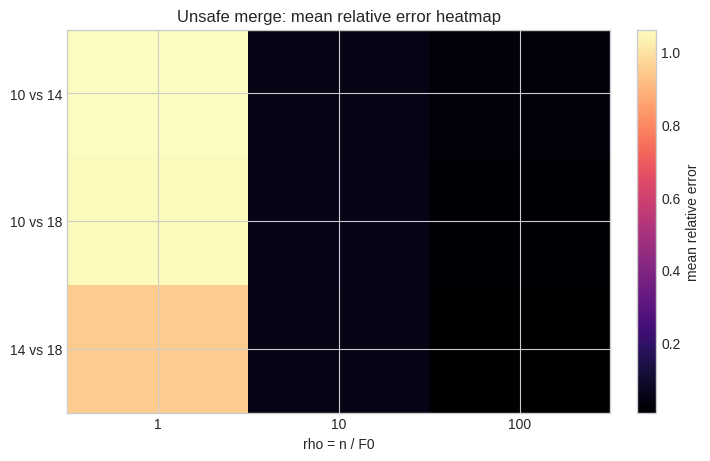

Saved: /home/daniele/Dev/satp-cpp/thesis/figures/results/merge_hpp_precision_mismatch_overview.png
Saved: /home/daniele/Dev/satp-cpp/thesis/figures/results/merge_hpp_precision_mismatch_unsafe_heatmap.png


In [4]:
reduce_plot = summary_pair_group[summary_pair_group['strategy'] == 'reduce_then_merge'].copy()
unsafe_plot = summary_pair_group[summary_pair_group['strategy'] == 'unsafe_naive_merge'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for pair_group in PAIR_GROUP_ORDER:
    sub = reduce_plot[reduce_plot['pair_group'] == pair_group]
    if sub.empty:
        continue
    axes[0].plot(sub['rho'], sub['merge_rel_mean'], marker='o', linewidth=2, label=pair_group)

axes[0].set_xscale('log')
axes[0].set_xlabel('rho = n / F0')
axes[0].set_ylabel('mean relative error vs exact union')
axes[0].set_title('Recoverable case: reduce_then_merge')
axes[0].legend(loc='best', fontsize=9)

for pair_group in PAIR_GROUP_ORDER:
    sub = unsafe_plot[unsafe_plot['pair_group'] == pair_group]
    if sub.empty:
        continue
    axes[1].plot(sub['rho'], sub['merge_rel_mean'], marker='o', linewidth=2, label=pair_group)

axes[1].set_xscale('log')
axes[1].set_xlabel('rho = n / F0')
axes[1].set_ylabel('mean relative error vs exact union')
axes[1].set_title('Recoverable case: unsafe naive merge')
axes[1].legend(loc='best', fontsize=9)

fig.savefig(OUT_DIR / 'merge_hpp_precision_mismatch_overview.png', dpi=200, bbox_inches='tight')
plt.show()

pivot = (
    unsafe_plot.pivot(index='pair_group', columns='rho', values='merge_rel_mean')
              .reindex(PAIR_GROUP_ORDER)
)

fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
im = ax.imshow(pivot.values, cmap='magma', aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([str(v) for v in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(list(pivot.index))
ax.set_xlabel('rho = n / F0')
ax.set_title('Unsafe merge: mean relative error heatmap')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('mean relative error')
fig.savefig(OUT_DIR / 'merge_hpp_precision_mismatch_unsafe_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

print('Saved:', OUT_DIR / 'merge_hpp_precision_mismatch_overview.png')
print('Saved:', OUT_DIR / 'merge_hpp_precision_mismatch_unsafe_heatmap.png')


In [5]:
key_findings = pd.DataFrame([
    {
        'finding': 'reduce_then_merge global mean relative error',
        'value': summary_global.query("strategy == 'reduce_then_merge'")['merge_rel_mean'].iloc[0],
        'note': 'Coincide con il seriale e con la baseline alla precisione piu\' bassa',
    },
    {
        'finding': 'unsafe_naive_merge global mean relative error',
        'value': summary_global.query("strategy == 'unsafe_naive_merge'")['merge_rel_mean'].iloc[0],
        'note': 'Il merge naive su mismatch di precisione degrada fortemente rispetto al caso recoverable corretto',
    },
    {
        'finding': 'worst-case unsafe_naive_merge',
        'value': summary_global.query("strategy == 'unsafe_naive_merge'")['merge_rel_max'].iloc[0],
        'note': 'Nel regime rho = 1 l\'errore arriva circa al 100%',
    },
])

display(key_findings)


,finding,value,note
0,reduce_then_merge global mean relative error,0.016651,Coincide con il seriale e con la baseline alla...
1,unsafe_naive_merge global mean relative error,0.363882,Il merge naive su mismatch di precisione degra...
2,worst-case unsafe_naive_merge,1.061378,Nel regime rho = 1 l'errore arriva circa al 100%
